In [1]:
import torch
import torch.nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import vae_model
import train_vae
import DataPipeline
from pathlib import Path
import matplotlib.pyplot as plt
from pytorch3d.loss import chamfer_distance
import numpy as np
np.bool8 = np.bool
from torch.utils.tensorboard.writer import SummaryWriter
import datetime
import DPM_diffusion
import DPM_train
from utils import *
from pytorch3d.loss import chamfer_distance

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = DataPipeline.PointCloudDataset(number_points=256, max_objects=3)
point_cloud = dataset
print(f"Number of training examples: {len(point_cloud)}")
dataloader = DataLoader(dataset, shuffle=False, batch_size=1)
epochs = 50000

vae = vae_model.PointnetVAE(number_points=256, in_channels=3, hidden_channels=64, latent_dim=32)
vae.load_state_dict(torch.load(Path.cwd() / Path("vae2.pt")))
variance_schedule = DPM_diffusion.VarianceSchedule(1000)
point_wise_net = DPM_diffusion.PointwiseNet(3, 32, hidden_dim=64, residual=True)
dpm_decoder = DPM_diffusion.DiffusionPoint(point_wise_net, variance_schedule)

num_parameters = sum(p.numel() for p in dpm_decoder.parameters() if p.requires_grad)
print(f"Trainable Parameters: {num_parameters / 1e6:.2f}M")



optimizer = torch.optim.Adam(dpm_decoder.parameters(), lr=2e-4)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=T_max // 4, gamma=0.5)
scheduler = None
log_path = Path(f"logs/training/{datetime.datetime.now().strftime('%b%d_%H_%M')}_dpm_decoder_2.pt")
writer = SummaryWriter(log_path)
latent = next(iter(dataloader))
latent, _ = vae.encoder(latent)

Number of training examples: 3
Trainable Parameters: 0.13M


Current Epoch Training Loss: 0.368983
Current Epoch Training Loss: 0.026133
Current Epoch Training Loss: 0.116984
Current Epoch Training Loss: 0.008211
Current Epoch Training Loss: 0.722463
Current Epoch Training Loss: 0.084562
Current Epoch Training Loss: 0.014062
Current Epoch Training Loss: 0.259241
Current Epoch Training Loss: 0.192373
Current Epoch Training Loss: 0.347500


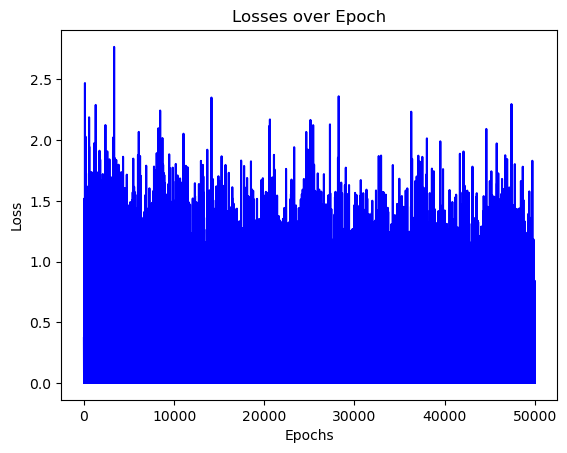

In [3]:
loss_history = []

for epoch in range(epochs):
    best_loss = 1e6
    decoder_loss = DPM_train.train_decoder(dataloader, dpm_decoder, vae.encoder, optimizer, writer)

    
    loss_history.append(decoder_loss)

    if scheduler is not None:
        scheduler.step()

    if decoder_loss < best_loss:
        best_loss = decoder_loss
        torch.save(dpm_decoder.state_dict(), Path.cwd() / Path("dpm_decoder_best_2.pt"))

    if epoch % 5000 == 0:
        print(f"Current Epoch Training Loss: {decoder_loss:.6f}")

torch.save(dpm_decoder.state_dict(), Path.cwd() / Path("dpm_decoder_end_2.pt"))

fig = plt.figure()

plt.title("Losses over Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(loss_history, color="b")
plt.plot()
plt.show()

In [39]:
for i, batch in enumerate(dataloader):
    latent = batch

In [40]:
latent, _ = vae.encoder(latent)

In [41]:
x_pred = dpm_decoder.sample(256, latent, 3)

In [25]:
print(x_pred.shape)

torch.Size([1, 256, 3])


In [42]:
x_pred = x_pred.squeeze().detach().cpu().numpy()

(256, 3)


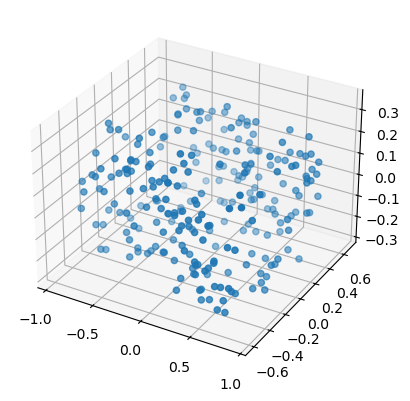

In [43]:
print(x_pred.shape)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(x_pred[:, 0], x_pred[:, 1], x_pred[:, 2])
plt.show()

In [44]:
point_cloud = dataset[2]

In [45]:
point_cloud = point_cloud.detach().cpu().numpy()

In [30]:
print(point_cloud.shape)

(256, 3)


(256, 3)


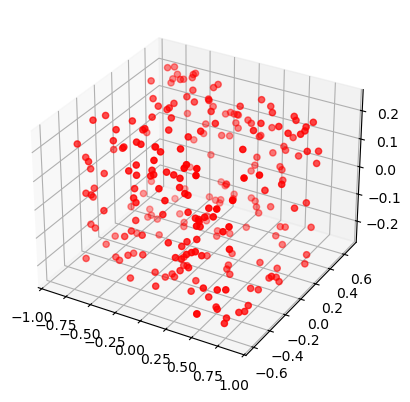

In [46]:
print(point_cloud.shape)
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(point_cloud[:, 0], point_cloud[:, 1], point_cloud[:, 2], color="r")
plt.show()

In [5]:
dpm_decoder.load_state_dict(torch.load(Path.cwd() / Path("dpm_decoder_end.pt")))

<All keys matched successfully>

In [47]:
visualize_comparison(point_cloud, x_pred)


Visualizing: Target is RED, Generated is BLUE.


In [48]:
x_pred = torch.tensor(x_pred).unsqueeze(dim=0)
point_cloud = torch.tensor(point_cloud).unsqueeze(dim=0)
print(chamfer_distance(x_pred, point_cloud))

(tensor(0.0144), None)


In [4]:
epochs = 50000

autoencoder = DPM_diffusion.AutoEncoder(256, 3, 64, 32, 1000)

num_parameters = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Trainable Parameters: {num_parameters / 1e6:.2f}M")



optimizer = torch.optim.Adam(autoencoder.parameters(), lr=2e-4)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=T_max // 4, gamma=0.5)
scheduler = None
log_path = Path(f"logs/training/{datetime.datetime.now().strftime('%b%d_%H_%M')}_dpm_autoencoder1.pt")
writer = SummaryWriter(log_path)

Trainable Parameters: 0.63M


In [ ]:
ae_loss_history = []
kld_loss_history = []

for epoch in range(epochs):
    best_loss = 1e6
    ae_loss, kld_loss = DPM_train.train_ae(dataloader, autoencoder, optimizer, writer)

    
    ae_loss_history.append(ae_loss)
    kld_loss_history.append(kld_loss)

    if scheduler is not None:
        scheduler.step()

    if ae_loss < best_loss:
        best_loss = ae_loss
        torch.save(dpm_decoder.state_dict(), Path.cwd() / Path("dpm_autoencoder_best1.pt"))

    if epoch % 5000 == 0:
        print(f"Current Epoch Training Loss: {decoder_loss:.6f}")

torch.save(dpm_decoder.state_dict(), Path.cwd() / Path("dpm_decoder_end_1.pt"))

fig = plt.figure()

plt.title("AE Loss over Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(ae_loss_history, color="b")
plt.plot()
plt.show()

fig = plt.figure()

plt.title("KLD Loss over Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(kld_loss_history, color="m")
plt.plot()
plt.show()